## 1. Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score
from math import radians, sin, cos, sqrt, atan2
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("unified_features_v3.csv")
print(f"Total rows loaded: {len(df)}")
print(df["traffic_source"].value_counts())
df.head()

Total rows loaded: 1039
traffic_source
DCC_2024_2025    973
SDCC_2024         65
DLR_2023           1
Name: count, dtype: int64


,location_id,lat,lon,traffic_volume,traffic_source,distance_to_nearest_substation_m,charger_count_nearby,road_density,ev_penetration_proxy
0,1,53.348754,-6.257607,241.52,DCC_2024_2025,31.6,0,219,0.049
1,2,53.354711,-6.246679,1540.22,DCC_2024_2025,36.1,0,63,0.049
2,3,53.351374,-6.250073,833.42,DCC_2024_2025,20.1,0,138,0.049
3,4,53.361145,-6.240513,289.96,DCC_2024_2025,67.7,0,49,0.049
4,5,53.355797,-6.292406,769.61,DCC_2024_2025,167.2,1,24,0.049


## 2. Separate SDCC (Display-Only)

SDCC uses SCOOT sensor system; DCC/DLR use SCATS. Mean traffic volume: SDCC=142 vs DCC=701 (~5x difference). Excluded from clustering; retained for map display only.

In [2]:
df_sdcc    = df[df["traffic_source"] == "SDCC_2024"].copy()
df_cluster = df[df["traffic_source"] != "SDCC_2024"].copy().reset_index(drop=True)

print(f"Clustering dataset : {len(df_cluster)} rows (DCC + DLR)")
print(f"SDCC display-only  : {len(df_sdcc)} rows")
print(f"DCC/DLR mean traffic : {df_cluster['traffic_volume'].mean():.1f}")
print(f"SDCC mean traffic    : {df_sdcc['traffic_volume'].mean():.1f}")

Clustering dataset : 974 rows (DCC + DLR)
SDCC display-only  : 65 rows
DCC/DLR mean traffic : 700.8
SDCC mean traffic    : 142.1


## 3. Gap Score Construction

Weighted combination of normalised demand signals:

```
gap_score = (0.7 * norm(traffic_volume) + 0.3 * norm(road_density))
           / (charger_count_nearby + 1)
```

**Role of gap_score in the pipeline:**
- Used for candidate site selection (Top 20% filter)
- Used for final ranking within clusters
- NOT fed into K-Means features (keeps clustering spatially driven)

**Assumptions documented:**
- Traffic volume is positively correlated with EV charging demand (consistent with literature)
- Road density indicates infrastructure suitability
- charger_count_nearby represents existing supply (deduplicated, 115 sites)

In [3]:
W_TRAFFIC = 0.7
W_ROAD    = 0.3

mms = MinMaxScaler()
df_cluster[["traffic_norm", "road_norm"]] = mms.fit_transform(
    df_cluster[["traffic_volume", "road_density"]]
)

df_cluster["gap_score"] = (
    (W_TRAFFIC * df_cluster["traffic_norm"] + W_ROAD * df_cluster["road_norm"])
    / (df_cluster["charger_count_nearby"] + 1)
)

print(f"Gap Score weights: traffic={W_TRAFFIC}, road_density={W_ROAD}")
print("Gap Score statistics:")
print(df_cluster["gap_score"].describe())

Gap Score weights: traffic=0.7, road_density=0.3
Gap Score statistics:
count    974.000000
mean       0.090013
std        0.061571
min        0.001181
25%        0.047267
50%        0.075211
75%        0.117430
max        0.702362
Name: gap_score, dtype: float64


## 4. Priority Candidate Selection (Top 20%)

In [4]:
CANDIDATE_PERCENTILE = 80
threshold = df_cluster["gap_score"].quantile(CANDIDATE_PERCENTILE / 100)
df_priority = df_cluster[df_cluster["gap_score"] >= threshold].copy().reset_index(drop=True)

print(f"Gap score threshold ({CANDIDATE_PERCENTILE}th percentile): {threshold:.4f}")
print(f"Candidate sites selected: {len(df_priority)} / {len(df_cluster)}")

Gap score threshold (80th percentile): 0.1296
Candidate sites selected: 195 / 974


## 5. Feature Preparation and Weighting

**Features for K-Means:**
- `traffic_volume` — demand proxy
- `charger_count_nearby` — existing supply
- `road_density` — infrastructure suitability
- `distance_to_nearest_substation_m` — grid accessibility proxy (ESB Networks, 7,780 substations)
- `lat`, `lon` — spatial position (WGS84; coordinates standardised alongside other features)

**Excluded:** `ev_penetration_proxy` (constant 0.049, zero spatial variance)

**Note on substation distance:** Downweighted to 0.1 after full-weight testing degraded Silhouette Score from 0.3287 to 0.2553 due to high substation density across Dublin. Interpreted as grid accessibility proxy only, not renewable capacity.

**Note on coordinates:** lat/lon are in WGS84 decimal degrees. After StandardScaler, they contribute equally with other features. The clustering objective is combined spatial-feature similarity, not purely geographic proximity.

In [5]:
FEATURES = [
    "traffic_volume", "charger_count_nearby", "road_density",
    "distance_to_nearest_substation_m", "lat", "lon"
]
DISTANCE_WEIGHT = 0.1
DISTANCE_IDX = FEATURES.index("distance_to_nearest_substation_m")

X = df_priority[FEATURES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:, DISTANCE_IDX] *= DISTANCE_WEIGHT

print(f"Features   : {FEATURES}")
print(f"Dist weight: {DISTANCE_WEIGHT}")
print(f"Input shape: {X_scaled.shape}")

Features   : ['traffic_volume', 'charger_count_nearby', 'road_density', 'distance_to_nearest_substation_m', 'lat', 'lon']
Dist weight: 0.1
Input shape: (195, 6)


## 6. K Selection — Elbow Method and Silhouette Score

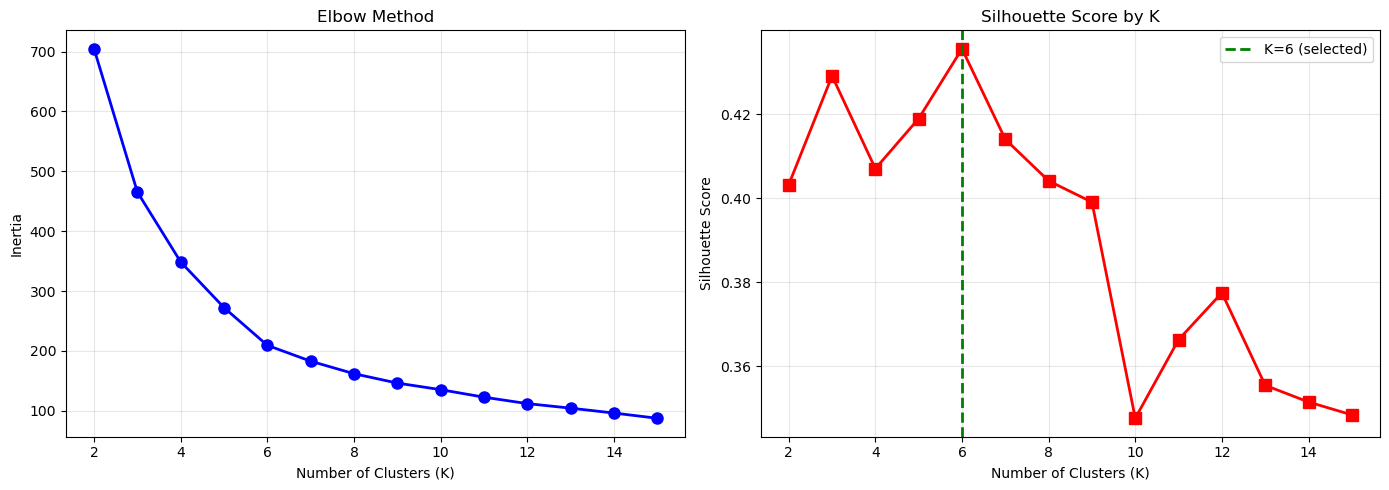

Silhouette scores by K:
  K= 2: 0.4033
  K= 3: 0.4291
  K= 4: 0.4071
  K= 5: 0.4190
  K= 6: 0.4356 <- selected
  K= 7: 0.4140
  K= 8: 0.4042
  K= 9: 0.3991
  K=10: 0.3477
  K=11: 0.3664
  K=12: 0.3775
  K=13: 0.3555
  K=14: 0.3515
  K=15: 0.3485


In [6]:
inertias, sil_scores = [], []
K_range = range(2, 16)

for k in K_range:
    X_s = scaler.transform(df_priority[FEATURES].values)
    X_s[:, DISTANCE_IDX] *= DISTANCE_WEIGHT
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_s)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_s, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(K_range, inertias, "bo-", linewidth=2, markersize=8)
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method")
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, sil_scores, "rs-", linewidth=2, markersize=8)
ax2.axvline(x=6, color="green", linestyle="--", linewidth=2, label="K=6 (selected)")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score by K")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("elbow_silhouette_v3.png", dpi=150, bbox_inches="tight")
plt.show()

print("Silhouette scores by K:")
for k, s in zip(K_range, sil_scores):
    marker = " <- selected" if k == 6 else ""
    print(f"  K={k:2d}: {s:.4f}{marker}")

## 7. Final K-Means (K=6)

K=6 selected based on:
- Elbow Method: inflection point at K=5–6
- Silhouette Score: peaks at K=6 (0.4356), highest across all K tested

**Three roles in the pipeline (kept separate):**
- Gap Score → candidate filtering and final ranking
- K-Means → spatial and feature-based grouping
- Silhouette Score → clustering quality evaluation

In [7]:
K = 6
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_priority["cluster"] = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, df_priority["cluster"])
print(f"Silhouette Score (K={K}): {score:.4f}")
print(f"\nVersion comparison:")
print(f"  v1 — 223 sites, DLR only, K=10          : 0.4235")
print(f"  v2 — 974 sites, DCC+DLR, K=10           : 0.3287")
print(f"  v3 — 974 sites, K=10, dist weight=0.1   : 0.3477")
print(f"  v3 — 974 sites, K=6  (adopted)          : {score:.4f}")
print(f"\nCluster sizes:")
print(df_priority["cluster"].value_counts().sort_index())

Silhouette Score (K=6): 0.4356

Version comparison:
  v1 — 223 sites, DLR only, K=10          : 0.4235
  v2 — 974 sites, DCC+DLR, K=10           : 0.3287
  v3 — 974 sites, K=10, dist weight=0.1   : 0.3477
  v3 — 974 sites, K=6  (adopted)          : 0.4356

Cluster sizes:
cluster
0    31
1    38
2    30
3    57
4    38
5     1
Name: count, dtype: int64


## 8. Spatially Separated Recommendation Selection

For each cluster:
1. Select the site with the highest gap score
2. Select a second site with high gap score AND at least 500m from the first

If total recommendations < 10, supplement from remaining high-gap candidates (still subject to 500m minimum distance from all already-selected sites).

In [8]:
def haversine_distance_m(lat1, lon1, lat2, lon2):
    """Geographic distance in metres (Haversine formula)."""
    R = 6_371_000
    lat1r, lat2r = radians(lat1), radians(lat2)
    dlat, dlon = radians(lat2-lat1), radians(lon2-lon1)
    a = sin(dlat/2)**2 + cos(lat1r)*cos(lat2r)*sin(dlon/2)**2
    return 2*R*atan2(sqrt(a), sqrt(1-a))

MIN_DISTANCE_M      = 500
MIN_RECOMMENDATIONS = 10
TARGET_RECOMMENDATIONS = 12

# Step 1: top-2 per cluster with distance constraint
selected_rows = []
for cluster_id, group in df_priority.groupby("cluster"):
    group = group.sort_values("gap_score", ascending=False)
    first = group.iloc[0]
    selected_rows.append(first)
    for _, candidate in group.iloc[1:].iterrows():
        if haversine_distance_m(first["lat"], first["lon"],
                                candidate["lat"], candidate["lon"]) >= MIN_DISTANCE_M:
            selected_rows.append(candidate)
            break

# Step 2: supplement if fewer than MIN_RECOMMENDATIONS
selected_ids = set(r.name for r in selected_rows)
if len(selected_rows) < MIN_RECOMMENDATIONS:
    remaining = (
        df_priority[~df_priority.index.isin(selected_ids)]
        .sort_values("gap_score", ascending=False)
    )
    for _, candidate in remaining.iterrows():
        if len(selected_rows) >= TARGET_RECOMMENDATIONS:
            break
        too_close = any(
            haversine_distance_m(sel["lat"], sel["lon"],
                                 candidate["lat"], candidate["lon"]) < MIN_DISTANCE_M
            for sel in selected_rows
        )
        if not too_close:
            selected_rows.append(candidate)

recommended_sites = (
    pd.DataFrame(selected_rows)
    .sort_values("gap_score", ascending=False)
    .reset_index(drop=True)
)
recommended_sites["rank"]                = recommended_sites.index + 1
recommended_sites["k_value"]             = K
recommended_sites["candidate_percentile"]= CANDIDATE_PERCENTILE
recommended_sites["minimum_spacing_m"]   = MIN_DISTANCE_M

print(f"Total recommendations : {len(recommended_sites)}")
print(f"Minimum required      : {MIN_RECOMMENDATIONS}")
print(f"\nRecommendations per cluster:")
print(recommended_sites["cluster"].value_counts().sort_index())
print(f"\nNote: clusters with 1 rec had no second candidate >= {MIN_DISTANCE_M}m away.")

Total recommendations : 11
Minimum required      : 10

Recommendations per cluster:
cluster
0    2
1    2
2    2
3    2
4    2
5    1
Name: count, dtype: int64

Note: clusters with 1 rec had no second candidate >= 500m away.


## 9. Recommendation Explainability

In [9]:
q75_traffic = df_cluster["traffic_volume"].quantile(0.75)
q75_road    = df_cluster["road_density"].quantile(0.75)

def explain(row):
    reasons = []
    if row["traffic_volume"] > q75_traffic:
        reasons.append("high traffic volume")
    if row["charger_count_nearby"] == 0:
        reasons.append("no existing chargers nearby")
    elif row["charger_count_nearby"] <= 2:
        reasons.append("low charger density")
    if row["road_density"] > q75_road:
        reasons.append("dense road network")
    if row["distance_to_nearest_substation_m"] < 100:
        reasons.append("close to grid substation")
    return "Recommended due to: " + ", ".join(reasons) if reasons else "High gap score"

recommended_sites["reason"] = recommended_sites.apply(explain, axis=1)

print("Recommendation explanations:")
for _, row in recommended_sites.iterrows():
    print(f"  Rank #{int(row['rank'])}: {row['reason']}")

Recommendation explanations:
  Rank #1: Recommended due to: high traffic volume, no existing chargers nearby
  Rank #2: Recommended due to: high traffic volume, no existing chargers nearby, dense road network
  Rank #3: Recommended due to: high traffic volume, no existing chargers nearby, dense road network, close to grid substation
  Rank #4: Recommended due to: high traffic volume, no existing chargers nearby, dense road network
  Rank #5: Recommended due to: no existing chargers nearby, dense road network, close to grid substation
  Rank #6: Recommended due to: high traffic volume, no existing chargers nearby, close to grid substation
  Rank #7: Recommended due to: high traffic volume, no existing chargers nearby, close to grid substation
  Rank #8: Recommended due to: high traffic volume, no existing chargers nearby
  Rank #9: Recommended due to: high traffic volume, no existing chargers nearby
  Rank #10: Recommended due to: high traffic volume, low charger density, dense road net

## 10. Sensitivity Analysis

**Group A:** K sensitivity (K=5, 6, 7)

**Group B:** Candidate threshold sensitivity (Top 10%, 20%, 30%)

Both groups report Silhouette Score and recommendation overlap with the adopted baseline (K=6, Top 20%).

In [10]:
# ── Group A: K sensitivity ──────────────────────────────────
print("Group A: K sensitivity")
print(f"  K  | Silhouette | Recs | Overlap with K=6")
print(f"  ---+------------+------+-----------------")

baseline_set = set(zip(
    recommended_sites["lat"].round(3),
    recommended_sites["lon"].round(3)
))

k_sensitivity = []
for k in [5, 6, 7]:
    X_s = scaler.transform(df_priority[FEATURES].values)
    X_s[:, DISTANCE_IDX] *= DISTANCE_WEIGHT
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_s)
    sil = silhouette_score(X_s, labels)
    df_t = df_priority.copy()
    df_t["cluster"] = labels
    sel = []
    for cid, grp in df_t.groupby("cluster"):
        grp = grp.sort_values("gap_score", ascending=False)
        first = grp.iloc[0]
        sel.append(first)
        for _, cand in grp.iloc[1:].iterrows():
            if haversine_distance_m(first["lat"],first["lon"],cand["lat"],cand["lon"])>=MIN_DISTANCE_M:
                sel.append(cand)
                break
    recs = pd.DataFrame(sel)
    recs_set = set(zip(recs["lat"].round(3), recs["lon"].round(3)))
    overlap = len(baseline_set & recs_set)
    marker = " <- adopted" if k == 6 else ""
    print(f"  K={k} | {sil:.4f}     | {len(recs):4d} | {overlap}{marker}")
    k_sensitivity.append((k, sil, len(recs), overlap))

# ── Group B: Top% sensitivity ────────────────────────────────
print(f"\nGroup B: Candidate threshold sensitivity")
print(f"  Threshold | Sites | Avg Gap Score | Overlap with Top20%")
print(f"  ----------+-------+---------------+--------------------")

pct_sensitivity = []
for pct in [0.10, 0.20, 0.30]:
    thr = df_cluster["gap_score"].quantile(1-pct)
    df_p = df_cluster[df_cluster["gap_score"]>=thr].copy().reset_index(drop=True)
    X_p = StandardScaler().fit_transform(df_p[FEATURES].values)
    X_p[:, DISTANCE_IDX] *= DISTANCE_WEIGHT
    km = KMeans(n_clusters=6, random_state=42, n_init=10)
    df_p["cluster"] = km.fit_predict(X_p)
    sel = []
    for cid, grp in df_p.groupby("cluster"):
        grp = grp.sort_values("gap_score", ascending=False)
        first = grp.iloc[0]
        sel.append(first)
        for _, cand in grp.iloc[1:].iterrows():
            if haversine_distance_m(first["lat"],first["lon"],cand["lat"],cand["lon"])>=MIN_DISTANCE_M:
                sel.append(cand)
                break
    recs = pd.DataFrame(sel)
    recs_set = set(zip(recs["lat"].round(3), recs["lon"].round(3)))
    overlap = len(baseline_set & recs_set)
    avg_gap = recs["gap_score"].mean()
    marker = " <- adopted" if pct == 0.20 else ""
    print(f"  Top {int(pct*100):3d}%  | {len(df_p):5d} | {avg_gap:.4f}        | {overlap}{marker}")
    pct_sensitivity.append((int(pct*100), len(df_p), avg_gap, overlap))

Group A: K sensitivity
  K  | Silhouette | Recs | Overlap with K=6
  ---+------------+------+-----------------
  K=5 | 0.4190     |    9 | 9
  K=6 | 0.4356     |   11 | 11 <- adopted
  K=7 | 0.4140     |   13 | 11

Group B: Candidate threshold sensitivity
  Threshold | Sites | Avg Gap Score | Overlap with Top20%
  ----------+-------+---------------+--------------------
  Top  10%  |    98 | 0.3155        | 11
  Top  20%  |   195 | 0.3155        | 11 <- adopted
  Top  30%  |   292 | 0.3155        | 11


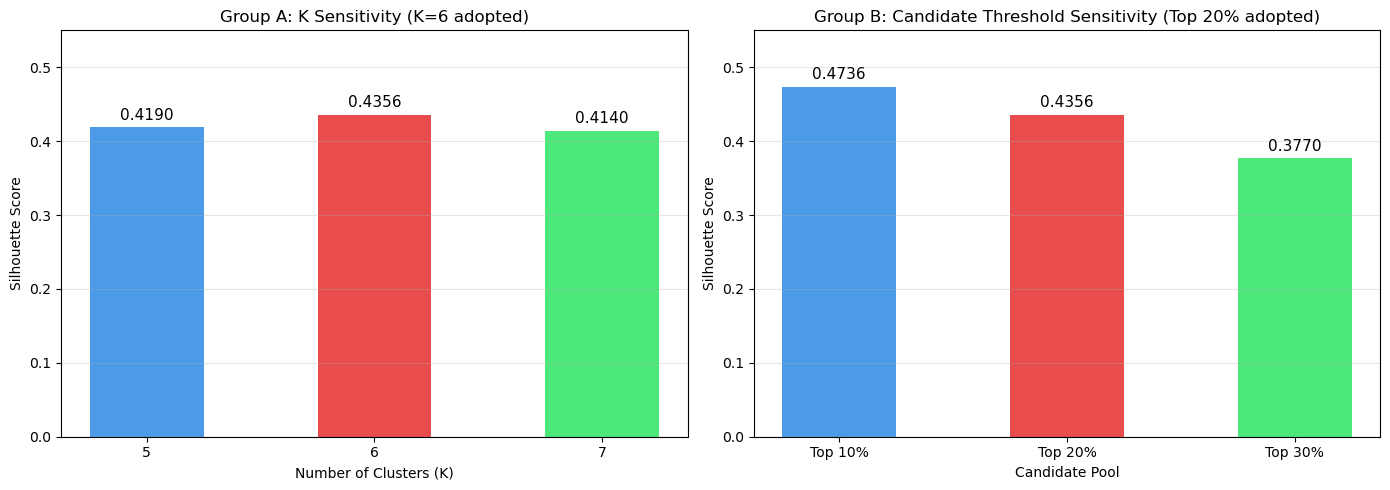

Saved: sensitivity_analysis.png


In [11]:
# ── Sensitivity plots ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

k_vals = [s[0] for s in k_sensitivity]
k_sils = [s[1] for s in k_sensitivity]
colors = ["#4C9BE8", "#E84C4C", "#4CE87A"]

ax1.bar([str(k) for k in k_vals], k_sils, color=colors, width=0.5)
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Silhouette Score")
ax1.set_title("Group A: K Sensitivity (K=6 adopted)")
ax1.set_ylim(0, 0.55)
for i, v in enumerate(k_sils):
    ax1.text(i, v+0.01, f"{v:.4f}", ha="center", fontsize=11)
ax1.grid(True, alpha=0.3, axis="y")

pct_vals = [s[0] for s in pct_sensitivity]
pct_sils_vals = []
for pct in [0.10, 0.20, 0.30]:
    thr = df_cluster["gap_score"].quantile(1-pct)
    df_p = df_cluster[df_cluster["gap_score"]>=thr].copy().reset_index(drop=True)
    X_p = StandardScaler().fit_transform(df_p[FEATURES].values)
    X_p[:, DISTANCE_IDX] *= DISTANCE_WEIGHT
    km = KMeans(n_clusters=6, random_state=42, n_init=10)
    pct_sils_vals.append(silhouette_score(X_p, km.fit_predict(X_p)))

ax2.bar([f"Top {p}%" for p in pct_vals], pct_sils_vals, color=colors, width=0.5)
ax2.set_xlabel("Candidate Pool")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Group B: Candidate Threshold Sensitivity (Top 20% adopted)")
ax2.set_ylim(0, 0.55)
for i, v in enumerate(pct_sils_vals):
    ax2.text(i, v+0.01, f"{v:.4f}", ha="center", fontsize=11)
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("sensitivity_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sensitivity_analysis.png")

## 11. Scenario Analysis — EV Penetration Rate

Pre-computes recommendations for three EV penetration scenarios aligned with Ireland's Draft National EV Charging Infrastructure Strategy 2026–2028 (Climate Action Plan target: 30% EV penetration by 2030).

**Logic:** Higher EV penetration → higher charging demand → traffic component scaled up

**Note:** If all sites scale proportionally, relative ordering may remain stable. The scenarios primarily show how gap score magnitudes change under different demand assumptions, and may result in the same recommended locations with higher priority scores.

In [12]:
scenarios = {"ev05": 0.05, "ev08": 0.08, "ev12": 0.12}

for name, ev_rate in scenarios.items():
    df_s = df_cluster.copy()
    df_s["gap_score"] = (
        (W_TRAFFIC * df_s["traffic_norm"] * (1 + ev_rate) + W_ROAD * df_s["road_norm"])
        / (df_s["charger_count_nearby"] + 1)
    )
    thr = df_s["gap_score"].quantile(0.80)
    df_p = df_s[df_s["gap_score"] >= thr].copy().reset_index(drop=True)

    X_p = StandardScaler().fit_transform(df_p[FEATURES].values)
    X_p[:, DISTANCE_IDX] *= DISTANCE_WEIGHT
    km = KMeans(n_clusters=6, random_state=42, n_init=10)
    df_p["cluster"] = km.fit_predict(X_p)

    sel = []
    for cid, grp in df_p.groupby("cluster"):
        grp = grp.sort_values("gap_score", ascending=False)
        first = grp.iloc[0]
        sel.append(first)
        for _, cand in grp.iloc[1:].iterrows():
            if haversine_distance_m(first["lat"],first["lon"],cand["lat"],cand["lon"])>=500:
                sel.append(cand)
                break

    recs = pd.DataFrame(sel).sort_values("gap_score",ascending=False).reset_index(drop=True)
    recs["rank"] = recs.index+1
    recs["ev_penetration"] = ev_rate
    recs["k_value"] = K
    recs["candidate_percentile"] = CANDIDATE_PERCENTILE
    recs[["rank","lat","lon","cluster","gap_score","ev_penetration",
          "k_value","candidate_percentile"]].to_csv(
        f"recommendations_{name}.csv", index=False
    )
    print(f"EV {int(ev_rate*100)}%: {len(recs)} recs, avg gap={recs['gap_score'].mean():.4f} -> recommendations_{name}.csv")

print("\nScenario Analysis complete.")

EV 5%: 11 recs, avg gap=0.3265 -> recommendations_ev05.csv
EV 8%: 11 recs, avg gap=0.3331 -> recommendations_ev08.csv
EV 12%: 11 recs, avg gap=0.3419 -> recommendations_ev12.csv

Scenario Analysis complete.


## 12. Export Final recommendations.csv

In [13]:
out_cols = [
    "rank", "lat", "lon", "cluster",
    "gap_score", "traffic_volume",
    "charger_count_nearby", "road_density",
    "distance_to_nearest_substation_m",
    "traffic_source", "reason",
    "k_value", "candidate_percentile", "minimum_spacing_m"
]
recommended_sites[out_cols].to_csv("recommendations.csv", index=False)
print("Saved: recommendations.csv")
print(recommended_sites[out_cols].to_string(index=False))

Saved: recommendations.csv
 rank       lat       lon  cluster  gap_score  traffic_volume  charger_count_nearby  road_density  distance_to_nearest_substation_m traffic_source                                                                                                             reason  k_value  candidate_percentile  minimum_spacing_m
    1 53.425378 -6.219091        5   0.702362         7731.50                     0             3                             138.2  DCC_2024_2025                                               Recommended due to: high traffic volume, no existing chargers nearby        6                    80                500
    2 53.343710 -6.308068        0   0.396861         3157.07                     0            95                             106.0  DCC_2024_2025                           Recommended due to: high traffic volume, no existing chargers nearby, dense road network        6                    80                500
    3 53.350749 -6.254447        4   

## 13. Map Visualisation

In [14]:
COLORS = ["red", "blue", "green", "purple", "orange", "darkred"]

m = folium.Map(location=[53.33, -6.25], zoom_start=11)

for _, row in df_cluster.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=3, color="lightgrey", fill=True, fill_opacity=0.3
    ).add_to(m)

for _, row in df_sdcc.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=4, color="steelblue", fill=False, weight=1.5,
        popup=f"SDCC (display only)<br>Traffic: {row['traffic_volume']:.0f}"
    ).add_to(m)

for _, row in df_priority.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=5, color=COLORS[int(row["cluster"])],
        fill=True, fill_opacity=0.5,
        popup=(
            f"Traffic: {row['traffic_volume']:.0f}<br>"
            f"Gap Score: {row['gap_score']:.4f}<br>"
            f"Substation: {row['distance_to_nearest_substation_m']:.0f}m<br>"
            f"Cluster: {int(row['cluster'])}"
        )
    ).add_to(m)

for _, row in recommended_sites.iterrows():
    folium.Marker(
        location=[row["lat"], row["lon"]],
        popup=(
            f"<b>Rank #{int(row['rank'])}</b><br>"
            f"Gap Score: {row['gap_score']:.4f}<br>"
            f"Traffic: {row['traffic_volume']:.0f}<br>"
            f"Nearby Chargers: {int(row['charger_count_nearby'])}<br>"
            f"Nearest Substation: {row['distance_to_nearest_substation_m']:.0f}m<br>"
            f"<i>{row['reason']}</i>"
        ),
        icon=folium.Icon(color="red", icon="bolt", prefix="fa")
    ).add_to(m)

m.save("kmeans_recommendations_v3.html")
print("Map saved: kmeans_recommendations_v3.html")
m

Map saved: kmeans_recommendations_v3.html


## 14. Limitations and Assumptions

| Item | Limitation |
|---|---|
| Traffic data | SCATS proxy for EV demand; no direct charging demand data available |
| Renewable score | EirGrid publishes national-level data only; no spatial differentiation possible |
| Substation distance | Grid accessibility proxy only; does not imply renewable capacity or green energy |
| EV penetration | CSO national figure (4.9%) applied uniformly; no county-level breakdown |
| SDCC data | SCOOT vs SCATS incompatibility; excluded from clustering, display only |
| Coordinates | WGS84 decimal degrees; not projected to metric CRS (EPSG:2157) |
| Scenario analysis | Proportional traffic scaling may not change site ranking; shows demand magnitude shift |

## 15. Summary

In [15]:
print("=== EcoCharge Dublin — K-Means Clustering Summary (v3 Final) ===")
print(f"Total sites loaded           : {len(df)}")
print(f"SDCC excluded (display only) : {len(df_sdcc)}")
print(f"Clustering dataset           : {len(df_cluster)} (DCC + DLR)")
print(f"Priority sites (Top {CANDIDATE_PERCENTILE}th pct)  : {len(df_priority)}")
print(f"Gap score weights            : traffic={W_TRAFFIC}, road={W_ROAD}")
print(f"Features                     : {FEATURES}")
print(f"Substation distance weight   : {DISTANCE_WEIGHT}")
print(f"K (clusters)                 : {K}")
print(f"Silhouette Score             : {score:.4f}")
print(f"Min spacing between recs     : {MIN_DISTANCE_M}m")
print(f"Total recommendations        : {len(recommended_sites)}")
print()
print("Output files:")
print("  recommendations.csv              — main output with metadata")
print("  recommendations_ev05/08/12.csv   — scenario analysis outputs")
print("  elbow_silhouette_v3.png          — K selection plot")
print("  sensitivity_analysis.png         — sensitivity analysis plot")
print("  kmeans_recommendations_v3.html   — interactive Folium map")
print()
print("Top 3 recommendations:")
for _, row in recommended_sites.head(3).iterrows():
    print(f"  Rank #{int(row['rank'])}: ({row['lat']:.4f}, {row['lon']:.4f})")
    print(f"    Gap={row['gap_score']:.4f} | Substation={row['distance_to_nearest_substation_m']:.0f}m")
    print(f"    {row['reason']}")

=== EcoCharge Dublin — K-Means Clustering Summary (v3 Final) ===
Total sites loaded           : 1039
SDCC excluded (display only) : 65
Clustering dataset           : 974 (DCC + DLR)
Priority sites (Top 80th pct)  : 195
Gap score weights            : traffic=0.7, road=0.3
Features                     : ['traffic_volume', 'charger_count_nearby', 'road_density', 'distance_to_nearest_substation_m', 'lat', 'lon']
Substation distance weight   : 0.1
K (clusters)                 : 6
Silhouette Score             : 0.4356
Min spacing between recs     : 500m
Total recommendations        : 11

Output files:
  recommendations.csv              — main output with metadata
  recommendations_ev05/08/12.csv   — scenario analysis outputs
  elbow_silhouette_v3.png          — K selection plot
  sensitivity_analysis.png         — sensitivity analysis plot
  kmeans_recommendations_v3.html   — interactive Folium map

Top 3 recommendations:
  Rank #1: (53.4254, -6.2191)
    Gap=0.7024 | Substation=138m
    Rec